In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/weatherHistory.csv")

In [65]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [66]:
df.shape

(96453, 12)

In [67]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [68]:
df['Precip Type'] = df['Precip Type'].fillna('unknown')

In [69]:
df = df[df["Precip Type"] != "unknown"]

In [70]:
df["Precip Type"].unique()

array(['rain', 'snow'], dtype=object)

In [71]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [72]:
df.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

In [73]:
df.shape

(95936, 12)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95936 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95936 non-null  object 
 1   Summary                   95936 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           95936 non-null  float64
 4   Apparent Temperature (C)  95936 non-null  float64
 5   Humidity                  95936 non-null  float64
 6   Wind Speed (km/h)         95936 non-null  float64
 7   Wind Bearing (degrees)    95936 non-null  float64
 8   Visibility (km)           95936 non-null  float64
 9   Loud Cover                95936 non-null  float64
 10  Pressure (millibars)      95936 non-null  float64
 11  Daily Summary             95936 non-null  object 
dtypes: float64(8), object(4)
memory usage: 9.5+ MB


<Axes: xlabel='Humidity', ylabel='Temperature (C)'>

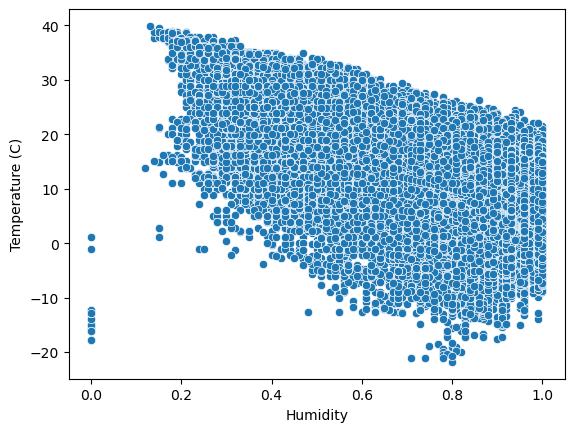

In [75]:
sns.scatterplot(x= df["Humidity"], y= df["Temperature (C)"])

In [76]:
df = df.drop(columns = "Apparent Temperature (C)")

In [77]:
df = df[df["Humidity"] != 0 ]

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
model = LinearRegression()

In [81]:
X = df[["Humidity"]]
y = df["Temperature (C)"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [83]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
y_pred = model.predict(X_test)

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [86]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

In [87]:
print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  6.04502825766193
mse:  54.81953520952683
score:  0.4070751303407021


<Axes: xlabel='Temperature (C)'>

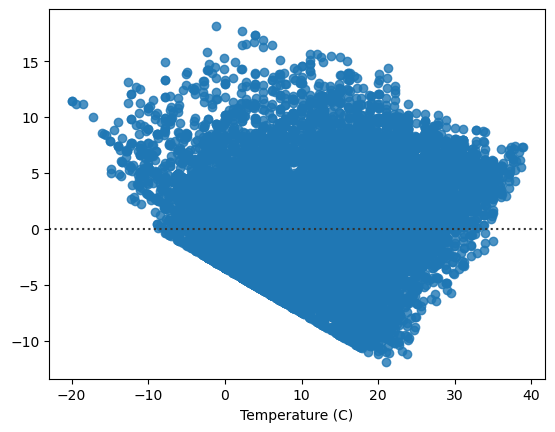

In [88]:
sns.residplot(x = y_test, y = y_pred)

In [89]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95914 entries, 0 to 96452
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Formatted Date          95914 non-null  object 
 1   Summary                 95914 non-null  object 
 2   Precip Type             95914 non-null  object 
 3   Temperature (C)         95914 non-null  float64
 4   Humidity                95914 non-null  float64
 5   Wind Speed (km/h)       95914 non-null  float64
 6   Wind Bearing (degrees)  95914 non-null  float64
 7   Visibility (km)         95914 non-null  float64
 8   Loud Cover              95914 non-null  float64
 9   Pressure (millibars)    95914 non-null  float64
 10  Daily Summary           95914 non-null  object 
dtypes: float64(7), object(4)
memory usage: 8.8+ MB


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95914 entries, 0 to 96452
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Formatted Date          95914 non-null  object 
 1   Summary                 95914 non-null  object 
 2   Precip Type             95914 non-null  object 
 3   Temperature (C)         95914 non-null  float64
 4   Humidity                95914 non-null  float64
 5   Wind Speed (km/h)       95914 non-null  float64
 6   Wind Bearing (degrees)  95914 non-null  float64
 7   Visibility (km)         95914 non-null  float64
 8   Loud Cover              95914 non-null  float64
 9   Pressure (millibars)    95914 non-null  float64
 10  Daily Summary           95914 non-null  object 
dtypes: float64(7), object(4)
memory usage: 8.8+ MB


In [92]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], errors='coerce')

/var/folders/sj/pj9lwv9d1r17b6cggf8ym3gc0000gn/T/ipykernel_2004/3152755485.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], errors='coerce')


In [93]:
X = df[["Humidity", "Wind Speed (km/h)", "Visibility (km)", "Pressure (millibars)"]]
y = df["Temperature (C)"]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [95]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [96]:
y_pred = model.predict(X_test)

In [97]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  5.697958422630818
mse:  50.080437398332975
score:  0.4583329336267915


In [98]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00+02:00,Partly Cloudy,rain,9.472222,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00+02:00,Partly Cloudy,rain,9.355556,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00+02:00,Mostly Cloudy,rain,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00+02:00,Partly Cloudy,rain,8.288889,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00+02:00,Mostly Cloudy,rain,8.755556,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [99]:
df["Precip Type"].unique()

array(['rain', 'snow'], dtype=object)

In [100]:
df = pd.get_dummies(df, columns=["Precip Type"], drop_first= True)

In [101]:
df.head()

,Formatted Date,Summary,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Precip Type_snow
0,2006-04-01 00:00:00+02:00,Partly Cloudy,9.472222,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,False
1,2006-04-01 01:00:00+02:00,Partly Cloudy,9.355556,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,False
2,2006-04-01 02:00:00+02:00,Mostly Cloudy,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,False
3,2006-04-01 03:00:00+02:00,Partly Cloudy,8.288889,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,False
4,2006-04-01 04:00:00+02:00,Mostly Cloudy,8.755556,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,False


In [133]:
pd.to_datetime("Formatted Date")

DateParseError: Unknown datetime string format, unable to parse: Formatted Date, at position 0

In [136]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

In [141]:
df_clean["Month"] = df["Formatted Date"]

/var/folders/sj/pj9lwv9d1r17b6cggf8ym3gc0000gn/T/ipykernel_2004/2608390714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Month"] = df["Formatted Date"]


In [143]:
df_clean.head()

,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Month
0,9.472222,0.89,14.1197,251.0,15.8263,1015.13,3
1,9.355556,0.86,14.2646,259.0,15.8263,1015.63,3
2,9.377778,0.89,3.9284,204.0,14.9569,1015.94,4
3,8.288889,0.83,14.1036,269.0,15.8263,1016.41,4
4,8.755556,0.83,11.0446,259.0,15.8263,1016.51,4


In [145]:
df_clean = df[["Temperature (C)","Month","Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]]

KeyError: "['Month'] not in index"

In [146]:
df_clean

,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Month
0,9.472222,0.89,14.1197,251.0,15.8263,1015.13,3
1,9.355556,0.86,14.2646,259.0,15.8263,1015.63,3
2,9.377778,0.89,3.9284,204.0,14.9569,1015.94,4
3,8.288889,0.83,14.1036,269.0,15.8263,1016.41,4
4,8.755556,0.83,11.0446,259.0,15.8263,1016.51,4
...,...,...,...,...,...,...,...
96448,26.016667,0.43,10.9963,31.0,16.1000,1014.36,9
96449,24.583333,0.48,10.0947,20.0,15.5526,1015.16,9
96450,22.038889,0.56,8.9838,30.0,16.1000,1015.66,9
96451,21.522222,0.60,10.5294,20.0,16.1000,1015.95,9


<Axes: >

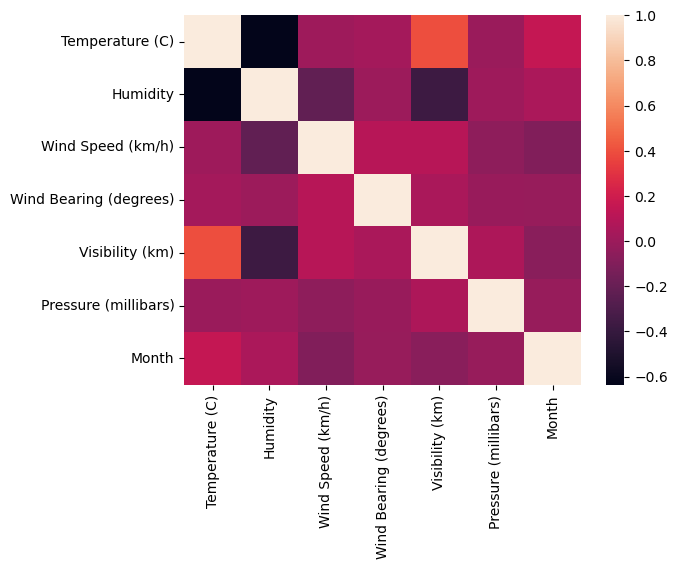

In [147]:
sns.heatmap(data = df_clean.corr())

In [148]:
X = df_clean.drop(columns=["Temperature (C)"])
y = df[["Temperature (C)"]]

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.20
)

In [150]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [151]:
y_pred = model.predict(X_test)

In [152]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  5.503510126926375
mse:  46.701640444371805
score:  0.4948778028212407


In [153]:
## Scaled
from sklearn.preprocessing import StandardScaler

In [154]:
scaler = StandardScaler()

In [155]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [156]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.20
)

In [157]:
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [158]:
y_pred_scaled = model.predict(X_test_scaled)

In [159]:
mae = mean_absolute_error(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
score = r2_score(y_test, y_pred_scaled)

print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  5.503510126926375
mse:  46.701640444371805
score:  0.4948778028212407


In [160]:
model.coef_

array([[-2.94700146e+01, -1.83189086e-01,  3.29971669e-03,
         4.42124686e-01, -1.44961015e-03,  5.04933277e-01]])

In [161]:

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

In [163]:
coef_df

,Feature,Coefficient
0,Humidity,-29.470015
1,Wind Speed (km/h),-0.183189
2,Wind Bearing (degrees),0.003300
3,Visibility (km),0.442125
4,Pressure (millibars),-0.001450
5,Month,0.504933


In [164]:
from sklearn.linear_model import LassoCV

In [165]:
model_lasso = LassoCV()

In [170]:
model_lasso.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,None
,verbose,False
,n_jobs,None


In [ ]:
y_lasso_pred = model_lasso.predict(X_test_scaled)

In [176]:
model_lasso.alpha_

np.float64(0.028970294117001104)

In [169]:
model_lasso.coef_

array([-2.85598013e+01, -1.77641916e-01,  3.22947336e-03,  4.55333874e-01,
       -1.46859912e-03,  5.01942108e-01])

In [ ]:
mae = mean_absolute_error(y_test, y_lasso_pred)
mse = mean_squared_error(y_test, y_lasso_pred)
score = r2_score(y_test, y_lasso_pred)

print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  5.511565764379633
mse:  46.7546220976743
score:  0.4943047563742279
